# SpaceX Stock Price — ML Analysis
**Dataset:** SPCX 30-min Interval | **Section A:** Machine Learning

## 1. Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [ ]:
df = pd.read_csv('spacex.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'], utc=True)
df.head()

,Datetime,Close,High,Low,Open,Volume
0,2026-06-12 15:30:00+00:00,161.309998,168.750000,150.000000,150.000000,90004242
1,2026-06-12 16:00:00+00:00,164.968994,167.770004,155.419998,161.350006,88532026
2,2026-06-12 16:30:00+00:00,173.740005,174.000000,163.070007,164.960007,56616741
3,2026-06-12 17:00:00+00:00,172.279999,176.520004,169.460007,173.720001,44169592
4,2026-06-12 17:30:00+00:00,173.330002,174.000000,168.000000,172.285004,26438783


## 3. Descriptive Statistics

In [ ]:
df.describe().round(2)

,Close,High,Low,Open,Volume
count,35.00,35.00,35.00,35.00,35.00
mean,188.56,191.42,184.02,187.60,27937753.46
std,19.29,19.73,19.48,19.97,23772630.92
min,161.27,162.77,150.00,150.00,7902359.00
25%,173.47,174.04,168.78,172.82,12629208.50
50%,183.40,187.86,181.54,183.32,16924193.00
75%,209.10,213.06,205.08,209.08,31011829.00
max,219.00,225.64,213.70,218.81,93751266.00


In [ ]:
df.isnull().sum()

Datetime    0
Close       0
High        0
Low         0
Open        0
Volume      0
dtype: int64

## 4. EDA — Seaborn Plots

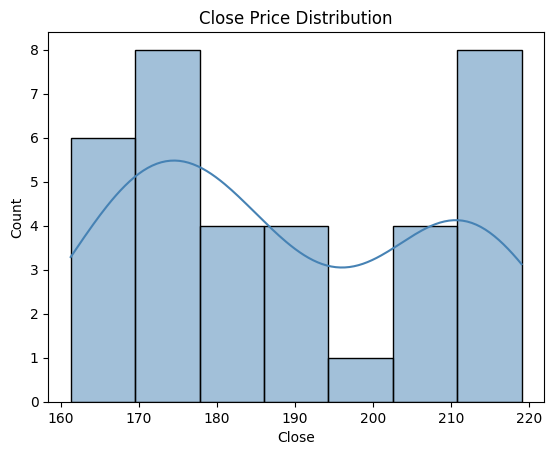

In [ ]:
sns.histplot(df['Close'], kde=True, color='steelblue')
plt.title('Close Price Distribution')
plt.show()

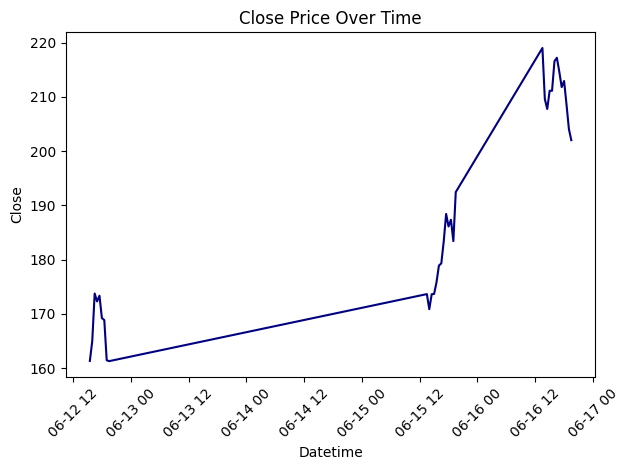

In [ ]:
sns.lineplot(data=df, x='Datetime', y='Close', color='navy')
plt.title('Close Price Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

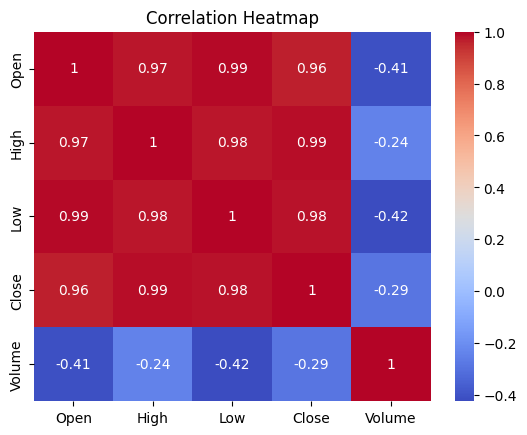

In [ ]:
sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

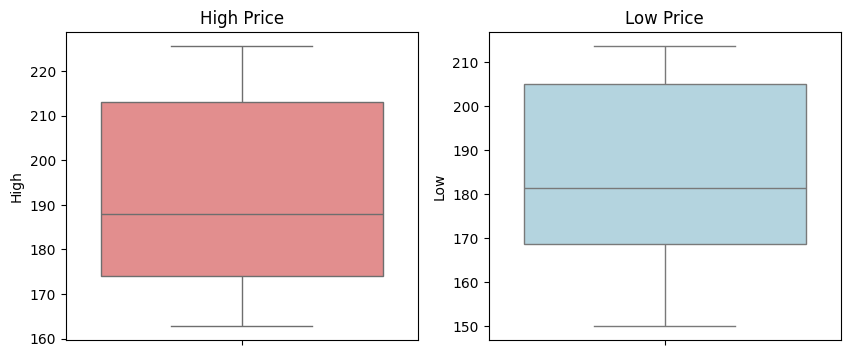

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['High'], ax=axes[0], color='lightcoral')
sns.boxplot(y=df['Low'],  ax=axes[1], color='lightblue')
axes[0].set_title('High Price')
axes[1].set_title('Low Price')
plt.show()

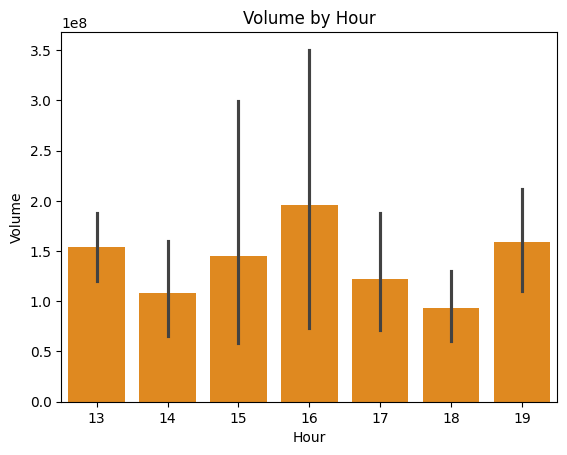

In [ ]:
df['Hour'] = df['Datetime'].dt.hour
sns.barplot(data=df, x='Hour', y='Volume', estimator=sum, color='darkorange')
plt.title('Volume by Hour')
plt.show()

## 5. Feature Engineering

In [ ]:
df['Price_Range']     = df['High'] - df['Low']
df['Price_Change']    = df['Close'] - df['Open']
df['Direction']       = (df['Close'] > df['Open']).astype(int)
df['Rolling_Close_3'] = df['Close'].rolling(3).mean().bfill()

df[['Price_Range','Price_Change','Direction','Rolling_Close_3']].head()

,Price_Range,Price_Change,Direction,Rolling_Close_3
0,18.750000,11.309998,1,166.672999
1,12.350006,3.618988,1,166.672999
2,10.929993,8.779999,1,166.672999
3,7.059998,-1.440002,0,170.329666
4,6.000000,1.044998,1,173.116669


## 6. Regression — Predict Close Price

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

features = ['Open','High','Low','Volume','Price_Range','Price_Change','Hour','Rolling_Close_3']
X = df[features]
y = df['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [ ]:
models = {
    'Linear Regression' : LinearRegression(),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    print(f"{name:25s} | MAE={mean_absolute_error(y_test,preds):.4f} | R²={r2_score(y_test,preds):.4f}")

Linear Regression         | MAE=0.0000 | R²=1.0000
Random Forest             | MAE=1.9762 | R²=0.9643
Gradient Boosting         | MAE=2.1146 | R²=0.9632


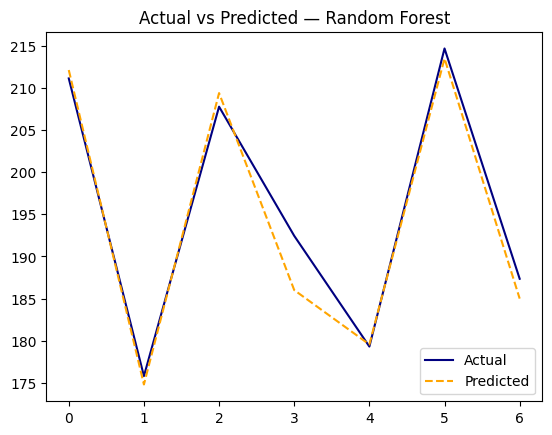

In [ ]:
best_preds = models['Random Forest'].predict(X_test_sc)
plt.plot(y_test.values, label='Actual', color='navy')
plt.plot(best_preds, label='Predicted', color='orange', linestyle='--')
plt.title('Actual vs Predicted — Random Forest')
plt.legend()
plt.show()

## 7. Classification — Predict Direction (Up/Down)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X2 = df[['Open','High','Low','Volume','Price_Range','Hour','Rolling_Close_3']]
y2 = df['Direction']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
X2_train_sc = scaler.fit_transform(X2_train)
X2_test_sc  = scaler.transform(X2_test)

In [ ]:
clfs = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
}

for name, clf in clfs.items():
    clf.fit(X2_train_sc, y2_train)
    preds = clf.predict(X2_test_sc)
    print(f"{name:22s} | Accuracy={accuracy_score(y2_test,preds):.4f}")

Logistic Regression    | Accuracy=0.4286
Decision Tree          | Accuracy=0.4286
Random Forest          | Accuracy=0.4286


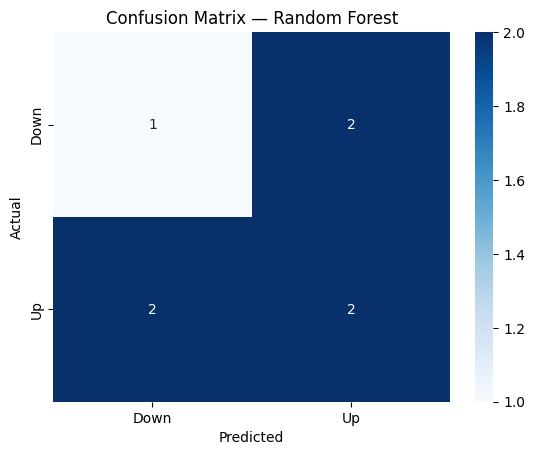

In [ ]:
best_clf = clfs['Random Forest']
cm = confusion_matrix(y2_test, best_clf.predict(X2_test_sc))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down','Up'], yticklabels=['Down','Up'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 8. Clustering — KMeans

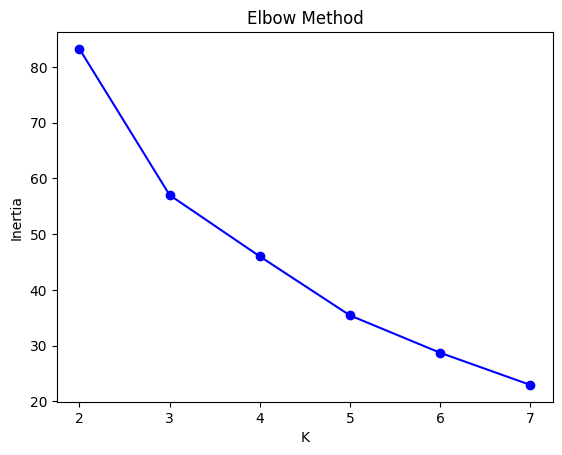

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X3 = df[['Close','Volume','Price_Range','Price_Change']]
X3_sc = StandardScaler().fit_transform(X3)

inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X3_sc).inertia_ for k in range(2,8)]
plt.plot(range(2,8), inertias, 'bo-')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

Silhouette Score: 0.3648


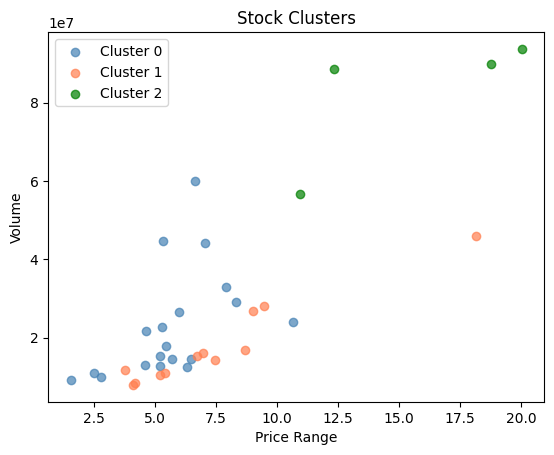

In [ ]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X3_sc)
print("Silhouette Score:", round(silhouette_score(X3_sc, df['Cluster']), 4))

for cl, color in zip([0,1,2], ['steelblue','coral','green']):
    sub = df[df['Cluster']==cl]
    plt.scatter(sub['Price_Range'], sub['Volume'], label=f'Cluster {cl}', alpha=0.7, color=color)
plt.xlabel('Price Range')
plt.ylabel('Volume')
plt.title('Stock Clusters')
plt.legend()
plt.show()

## 9. Ensemble Learning

In [ ]:
from sklearn.ensemble import AdaBoostRegressor, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

ensembles = {
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'AdaBoost'          : AdaBoostRegressor(n_estimators=100, random_state=42),
    'Bagging'           : BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=50, random_state=42),
}

for name, model in ensembles.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    cv = cross_val_score(model, X_train_sc, y_train, cv=3, scoring='r2').mean()
    print(f"{name:22s} | MAE={mean_absolute_error(y_test,preds):.4f} | R²={r2_score(y_test,preds):.4f} | CV={cv:.4f}")

Random Forest          | MAE=1.9762 | R²=0.9643 | CV=0.9555
Gradient Boosting      | MAE=2.1146 | R²=0.9632 | CV=0.9600
AdaBoost               | MAE=2.5070 | R²=0.9550 | CV=0.9564
Bagging                | MAE=2.1659 | R²=0.9620 | CV=0.9485


## 10. Save Models

In [ ]:
import pickle

pickle.dump(models['Random Forest'],     open('model_regressor.pkl',  'wb'))
pickle.dump(clfs['Random Forest'],       open('model_classifier.pkl', 'wb'))
pickle.dump(ensembles['Random Forest'],  open('model_ensemble.pkl',   'wb'))

print("Models saved.")

Models saved.
